In [605]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import scipy
import pickle
import os
path = os.getcwd()

from neurolib.models.alnSimp import ALNModelSimp
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [606]:
aln = ALNModelSimp()

aln.params.ext_exc_current = 3.
aln.params.ext_inh_current = 1.
#aln.params.sigmae = 2.

#aln.params.mufe_init = np.array( [aln.params.ext_exc_current] )
def setinit(mufe_st):
    aln.params.mufe_init = np.array( [mufe_st] )
    aln.params.rates_exc_init = np.array( [[0.0]])

mufe_start= 2.5


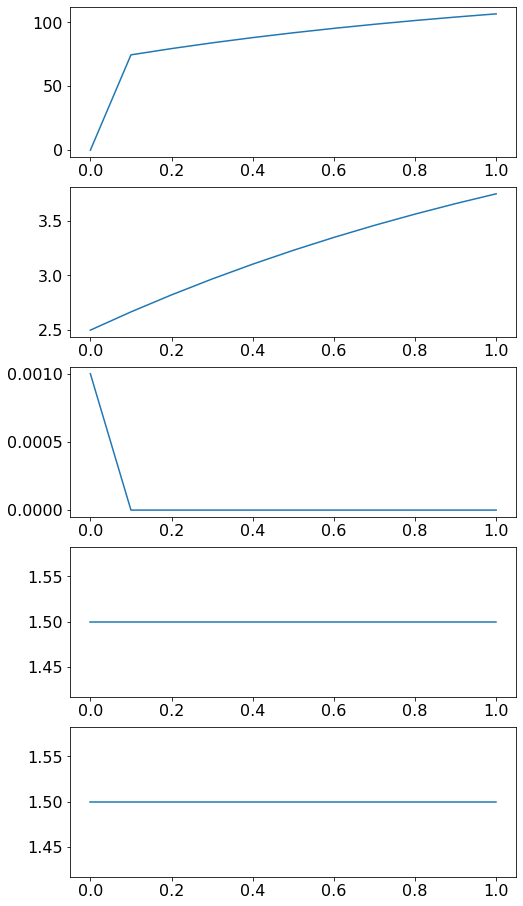

In [607]:
dur = 1.
dur_pre = 0.
dur_post = 0.
aln.params.duration = dur

control0 = aln.getZeroControl()
target = aln.getZeroTarget()

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-16
incl_step = int(1. + aln.params.duration/aln.params.dt)
test_step = 1e-12

control1 = aln.getZeroControl()
control1[0,0,:] += 2.
#control1[0,0,:] += np.sin(5.*np.arange(0,dur+aln.params.dt,aln.params.dt))

#aln.params.cee = 0.
#aln.params.Ke = 0.
#aln.params.Jee = 1e-30

setinit(mufe_start)
aln.run(control=control1)

target[:,0,:] = aln.rates_exc[:,:]
#print(aln.rates_exc)
#print(aln.state["mufe"][0,:])
#print(aln.params.sigmae_ext)
#print(aln.state["tau_exc"][0,:])

fig, ax = plt.subplots(5, figsize=(8, 16))
ax[0].plot(aln.t, aln.rates_exc[0,:])
ax[1].plot(aln.t, aln.state["mufe"][0,:])
ax[2].plot(aln.t, aln.state["seev"][0,:])
ax[3].plot(aln.t, aln.state["sigmae_f"][0,:])
#ax[1,0].axhline(aln.params.ext_exc_current, aln.t[0], aln.t[-1], c="red", linestyle=":")
ax[4].plot(aln.t, aln.state["tau_exc"][0,:])

In [610]:
max_cntrl = 1. * 5.
start_step = 30.
cost_params = [1.0, 1.0, 0.0]

setinit(mufe_start)
init_state_vars = np.array( [aln.rates_exc[0,0], mufe_start, mufi_start] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()
control2 += 3.

max_it = 100

A1_bestControlA, A1_bestStateA, A1_costA, runtime = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  34.07804781507587
RUN  1 , total integrated cost =  29.63327254049513
RUN  2 , total integrated cost =  29.527734181360483
RUN  3 , total integrated cost =  29.41728976177134
RUN  4 , total integrated cost =  29.0467716156961
RUN  5 , total integrated cost =  28.829290329778942
RUN  6 , total integrated cost =  28.828960717075727
RUN  7 , total integrated cost =  28.82885146789185
RUN  8 , total integrated cost =  28.828810295630856
RUN  9 , total integrated cost =  28.828793018728923
RUN  10 , total integrated cost =  28.828789095159223
RUN  11 , total integrated cost =  28.828787184478287
RUN  12 , total integrated cost =  28.828786948662284
RUN  13 , total integrated cost =  28.82878688980434
RUN  14 , total integrated cost =  28.828786860387893
RUN  15 , total integrated cost =  28.828786856711517
RUN  16 , total integrated cost =  28.8287868548734
RUN  17 , total integrated cost =  28.82878685395437
RUN  18 , total integrated cost 

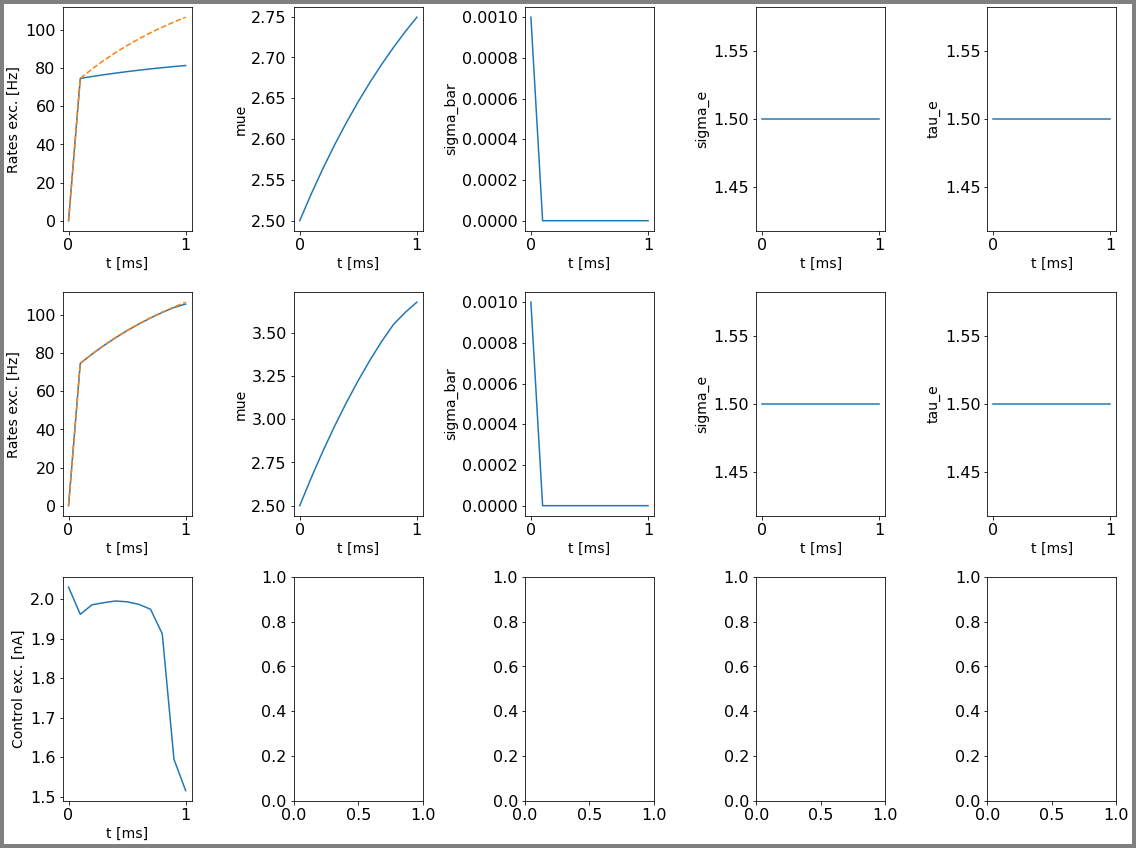

In [581]:
init_state_vars = np.array( [aln.rates_exc[0,0], mufe_start] )
plotFunc.plot_control(aln, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a1simp')

In [609]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 10

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = aln.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  34.87789565394142
RUN  1 , total integrated cost:  12.561185873172295
RUN  2 , total integrated cost:  4.082852495993204
RUN  3 , total integrated cost:  3.4690660402432427
RUN  4 , total integrated cost:  3.4491116944556355
RUN  5 , total integrated cost:  3.447079570828919
 max iteration reached, step size =  2.5e-323
change helped, counter =  2
RUN  6 , total integrated cost:  3.4448340612984536
change helped, counter =  1
RUN  7 , total integrated cost:  3.444035290123365
change helped, counter =  1
change helped, counter =  2
change helped, counter =  1
change helped, counter =  2
change helped, counter =  2
RUN  8 , total integrated cost:  3.4438764647542093
change helped, counter =  1
change helped, counter =  3
RUN  9 , total integrated cost:  3.4438573233341914
change helped, counter =  1
RUN  10 , total integrated cost:  3.443851032122898
Improved over  10  iterations by  91  percent.


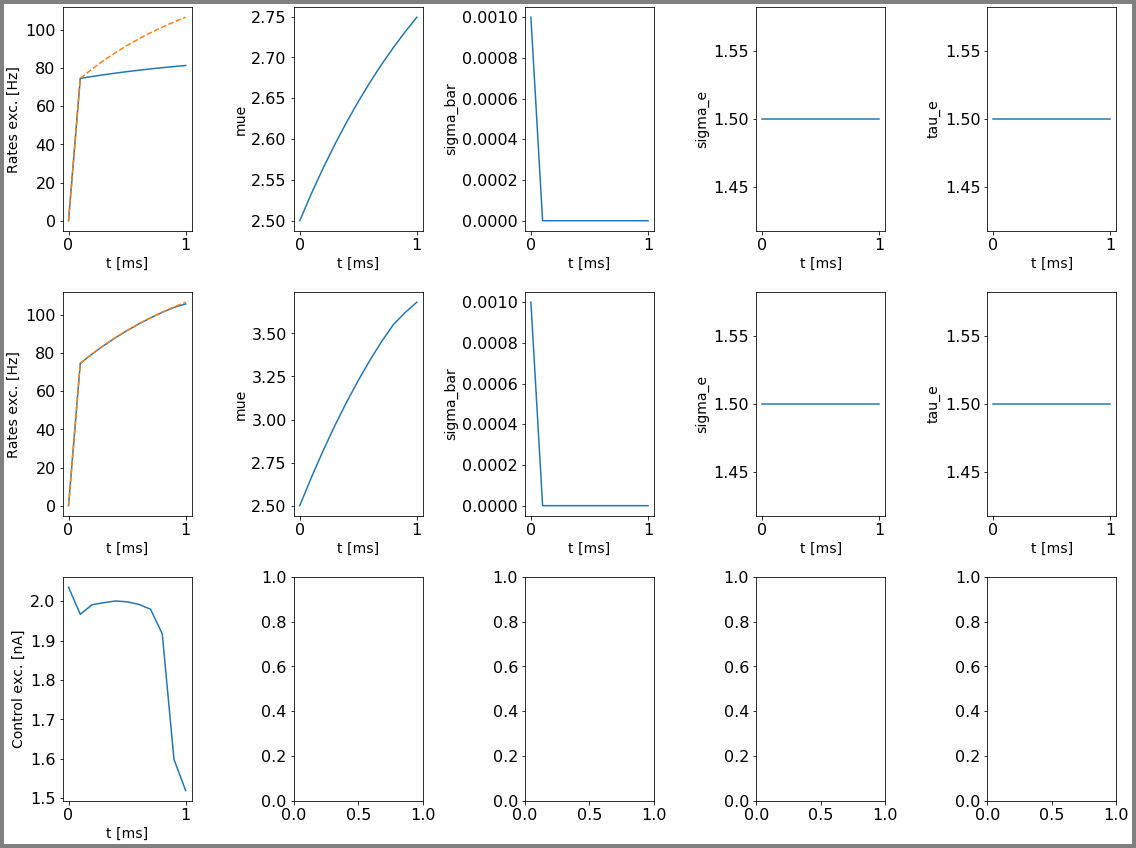

In [579]:
plotFunc.plot_control(aln, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

In [ ]:
rates = aln.params.precalc_r * 1e3
print("sigmarange = ", aln.params.sigmarange[0], aln.params.sigmarange[-1], len(aln.params.sigmarange))
print("rates range = ", aln.params.Irange[0], aln.params.Irange[-1], len(aln.params.Irange))

plt.figure(figsize=(20,10))
plt.imshow(rates.T)
plt.colorbar()
plt.show()

In [599]:
def getindex(lower, upper, length, x_):
    return int( (x_ - lower) * (length-1) / (upper - lower) )

def get_value(lower, upper, length, index_):
    return lower + index_ * (upper - lower) / (length-1)

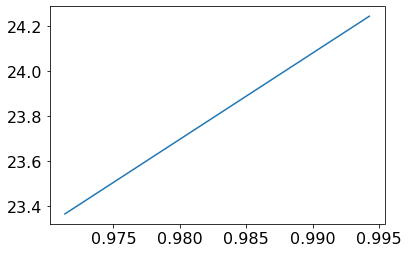

87 14
0.022922636103151817
24.244548325931042
38.199826423477596


In [604]:
index_sigma = getindex(aln.params.sigmarange[0], aln.params.sigmarange[-1], len(aln.params.sigmarange), 1.5)
index_mu = getindex(aln.params.Irange[0], aln.params.Irange[-1], len(aln.params.Irange), 1.)
rates_sigmaStat = rates[:,index_sigma]
plt.plot(aln.params.Irange[index_mu-1:index_mu+1], rates_sigmaStat[index_mu-1:index_mu+1])
plt.show()

mu0 = get_value(aln.params.Irange[0], aln.params.Irange[-1], len(aln.params.Irange), index_mu)
mu1 = get_value(aln.params.Irange[0], aln.params.Irange[-1], len(aln.params.Irange), index_mu+1)

sigma0 = get_value(aln.params.sigmarange[0], aln.params.sigmarange[-1], len(aln.params.sigmarange), index_sigma)
sigma1 = get_value(aln.params.sigmarange[0], aln.params.sigmarange[-1], len(aln.params.sigmarange), index_sigma+1)

print(index_mu, index_sigma)
print(aln.params.dI)
print(rates[index_mu, index_sigma])
print( (rates[index_mu+1,index_sigma] - rates[index_mu,index_sigma]) / (mu1-mu0) )

(350, 64, 2)


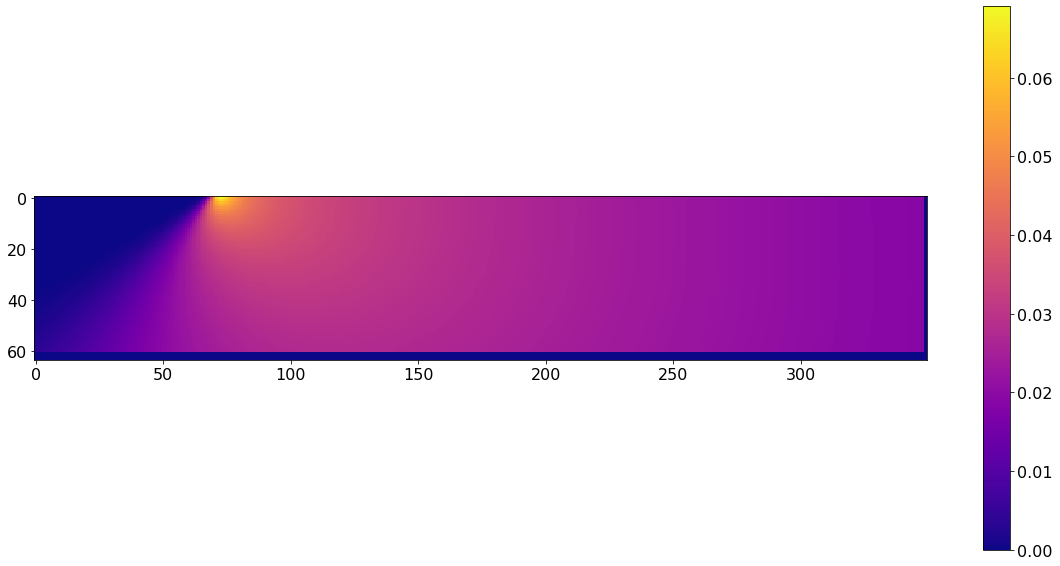

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


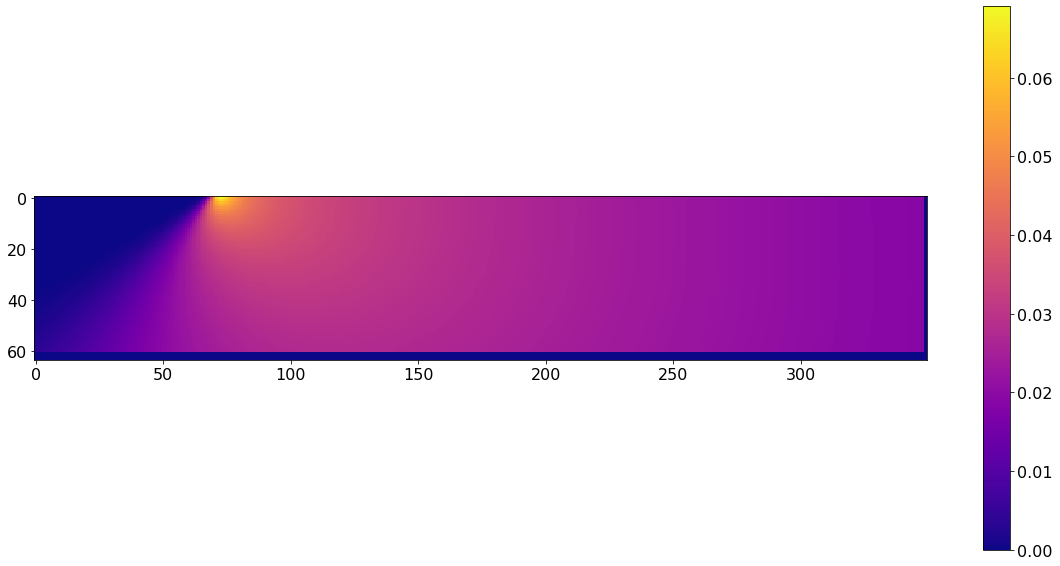

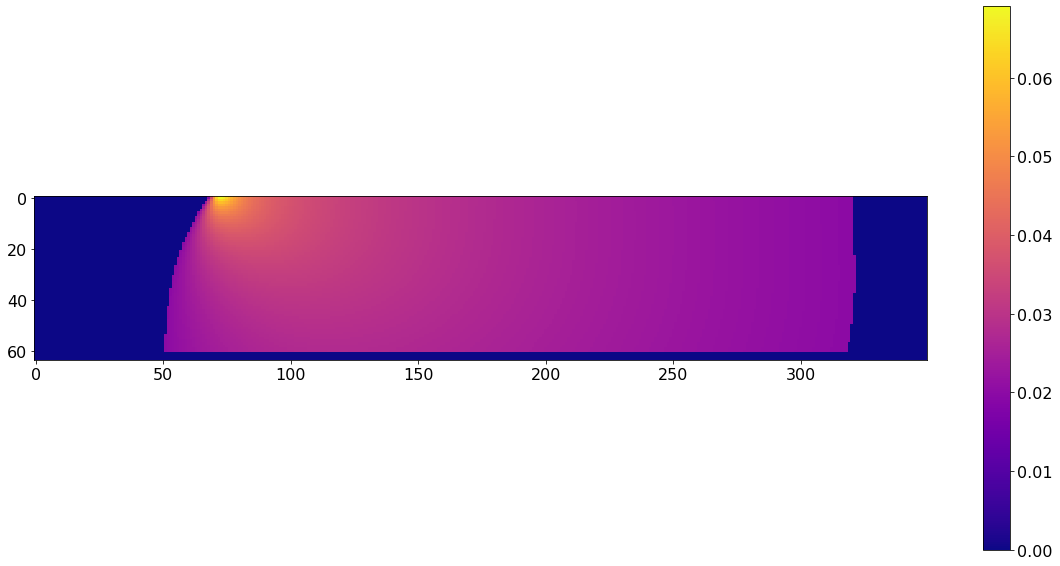

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()